In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.signal import savgol_filter

In [2]:
#Funcion para calcular el FM de la imagen propuesta en el paper "Image SharpnessMeasure for Blurred Images in Frequency Domain“
def calc_fm (imagen):
    img_fft = np.fft.fft2(imagen)
    img_fft_shift = np.fft.fftshift(img_fft)
    img_fft_abs = np.abs(img_fft_shift)
    max_fft = np.max(img_fft_abs)
    count_over = np.sum(img_fft_abs > max_fft/1000)
    return(count_over/img_fft_abs.size)

In [3]:
#unsharp masking- recibe la imagen original y el factor k y devuelve la imagen reenfocada
def unsharp_masking(imagen_in,k_in):
    gauss = cv.GaussianBlur(imagen_in, (7,7), 0.5) #tamaño del kernel, desviacion standard
    return(cv.addWeighted(imagen_in, k_in+1, gauss, -k_in, 0))
    

In [4]:
#captura del ROI
def captura_roi(frame_in,pct):
    alto, ancho, chan = frame_in.shape     
    return(frame_in[int(((alto/2)-alto*(pct/2))):int(((alto/2)+alto*(pct/2))),int(((ancho/2)-ancho*(pct/2))):int(((ancho/2)+ancho*(pct/2)))])   

In [5]:
#dibuja area ROI sobre imagen
def dibuja_roi(frame_in_dib,pct):
    alto, ancho, chan = frame_in_dib.shape   
    bbox_start = (int(((ancho/2)-ancho*(pct/2))),int(((alto/2)-alto*(pct/2))))
    bbox_end = (int(((ancho/2)+ancho*(pct/2))),int(((alto/2)+alto*(pct/2))))
    return(cv.rectangle(frame_in_dib, bbox_start, bbox_end, (0,255,0),2))   

In [6]:
    # Mostrar graficos
def mostrar_graficos (fm_list_in,max_fm_in,max_focus_in,fm_list_roi_in,max_focus_roi_in,fm_list_roi_sharp_in,max_fm_roi_in,pct_roi) :
                           #1      2            3          4                 5                 6                7            8
    #1 valores FM obtendidos sobre las frames originales,
    #2 FM maximo,
    #3 imagen con maximo foco,
    #4 valores FM obtenidos sobre el ROI, 
    #5 frame ROI con maximo foco
    #6 FM obtenidos luego aplicar unsharp masking,
    #7 FM maximo en el ROI,
    #8 porcenaje del frame correspondiente al ROI
    plt.figure(figsize=(12, 10)) 
    # Primera fila de imágenes
    plt.subplot(2,2,1)
    plt.title(f'Curva de enfoque')
    plt.scatter(list(range(len(fm_list_in))),fm_list_in, label="FM Original")
    plt.legend(loc='upper left')
    plt.subplot(2,2,2)
    plt.title(f'Imagen con maximo enfoque : {round(max_fm_in,4)}')
    plt.imshow(cv.cvtColor(max_focus_in, cv.COLOR_BGR2RGB))
    plt.axis("off")
    plt.subplot(2,2,3)
    plt.title(f'Curva de enfoque ROI')
    max_focus_con_roi = dibuja_roi(max_focus_in,pct_roi)#agrega area de roi al frame de maximo enfoque
    plt.scatter(list(range(len(fm_list_roi_in))),fm_list_roi_in,label="FM Original")
    plt.plot(fm_list_roi_sharp_in, color = 'red', label="FM unsharp masking")
    plt.legend(loc='upper left')
    plt.subplot(2,2,4)
    plt.title(f'Imagen con maximo enfoque ROI : {round(max_fm_roi_in,4)}')
    plt.imshow(cv.cvtColor(max_focus_con_roi, cv.COLOR_BGR2RGB))
    plt.axis("off")
    plt.tight_layout()
    plt.show()                    
                    

In [7]:
# Realiza el analisis del video
def fm_analisis (video, pct_roi,pct_fm_roi_ini,pct_fm_roi_fin,k_orig):
    video_path = video
    captura_video = cv.VideoCapture(video_path)
    #vectores para almacenar los valores FM de todas las imagenes tanto de las originales como de los sectores ROI
    fm_list= []
    fm_list_roi= []
    fm_list_roi_sharp = []
    ret=True
    max_fm = 0
    max_fm_roi = 0
    pic_fm = 0
    pic_fm_roi = 0
    min_fm = 0
    comienzo_unsharp = False
    fin_unsharp = False
    pasa_max = False
    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
    else:
        while ret: #recorre todos los frames uno a uno
            ret, frame = captura_video.read()
            if ret:
                frame_roi=captura_roi(frame,pct_roi) #obtiene el area ROI 
                pic_fm_roi =calc_fm(frame_roi) #calcula el FM de la imagen
                pic_fm =calc_fm(frame) #calcula el FM del ROI la imagen
                fm_list.append(pic_fm) #agrega el FM a la lista que contendra todos los FM para graficar
                fm_list_roi.append(pic_fm_roi) #agrega el FM del ROI a la lista  para graficar 
                if pic_fm >= max_fm: #si el fm de la imagen es mayor que el maximo
                    max_fm = pic_fm # el nuevo maximo es el FM de la imagen
                    max_focus=frame #guarda la imagen del maximo FM para mostrarla
                    # max_focus_con_roi = dibuja_roi(max_focus,pct_roi)
                if pic_fm_roi >= max_fm_roi:#si el fm del ROI es mayor que el maximo
                    max_fm_roi = pic_fm_roi # el nuevo maximo de ROI es el FM de la imagen
                    max_focus_roi=frame_roi #guarda la imagen del ROI de maximo FM para mostrarla   
 #recalculo de FM post unsharp masking de frames dentro de % indicado del max FM          
        captura_video.set(cv.CAP_PROP_POS_FRAMES, 0)
        ret=True
        while ret: #recorre todos los frames uno a uno
            ret, frame = captura_video.read()
            if ret:
                frame_roi=captura_roi(frame,pct_roi) #obtiene el area ROI 
                frame_roi_unsharp=unsharp_masking(frame_roi,k_orig)#aplica unsharp masking pasando el k
                pic_fm_roi =calc_fm(frame_roi) #calcula el FM de la imagen
                if pic_fm_roi == max_fm_roi: #para saber cuando comienza a descender 
                    pasa_max = True
                if not comienzo_unsharp and not pasa_max: #si no comenzo el unsharp y no llego al punto maximo
                    if  (max_fm_roi - pic_fm_roi <=  max_fm_roi * pct_fm_roi_ini) and (max_fm_roi - pic_fm_roi >= max_fm_roi * pct_fm_roi_fin) :
                        unsharp_fm =calc_fm(frame_roi_unsharp)#recalcula FM
                        fm_list_roi_sharp.append(unsharp_fm)#agrega FM post unsharp a la lista de FM parar graficar
                        if not comienzo_unsharp: #si encontro un punto dentro del rango indica el comienzo del unsharp
                            comienzo_unsharp = True #empieza el area de unmask
                    else: #si no entra en el rango usa el FM original        
                        fm_list_roi_sharp.append(pic_fm_roi)#agrega a la lista de FM parar graficar
                elif comienzo_unsharp and not pasa_max: #si comenzo el unsharp que lo haga para todos los puntos siguientes esten o no dentro del rango   
                    if  (max_fm_roi - pic_fm_roi >= max_fm_roi * pct_fm_roi_fin) :
                        unsharp_fm =calc_fm(frame_roi_unsharp)#recalcula FM
                        fm_list_roi_sharp.append(unsharp_fm)#agrega FM post unsharp a la lista de FM parar graficar
                    else: #si  el punto esta afuera del margen superior del rango no aplica unsharp
                        fm_list_roi_sharp.append(pic_fm_roi)#agrega a la lista de FM parar graficar
                elif comienzo_unsharp and pasa_max and not fin_unsharp: #si comenzo unsharp y paso el maximo pero no encontro un punto afuera aun   
                    if  (max_fm_roi - pic_fm_roi <=  max_fm_roi * pct_fm_roi_ini) and (max_fm_roi - pic_fm_roi >= max_fm_roi * pct_fm_roi_fin) :
                        unsharp_fm =calc_fm(frame_roi_unsharp)#recalcula FM
                        fm_list_roi_sharp.append(unsharp_fm)#agrega FM post unsharp a la lista de FM parar graficar
                    else: #si el punto esta afuera del rango y es el primero indica el fin del unsharp
                            if (max_fm_roi - pic_fm_roi > max_fm_roi * pct_fm_roi_ini):
                                fm_list_roi_sharp.append(pic_fm_roi)#agrega a la lista de FM parar graficar
                                fin_unsharp = True
                            else: # si el punto esta aun por encima del rango no aplica unsharp        
                                fm_list_roi_sharp.append(pic_fm_roi)#agrega a la lista de FM parar graficar
                elif fin_unsharp: #si en la bajada llego a un punto sin unsharp, todos los siguientes siguen sin unsharp        
                        fm_list_roi_sharp.append(pic_fm_roi)#agrega a la lista de FM parar graficar  
    mostrar_graficos(fm_list,max_fm,max_focus,fm_list_roi,max_focus_roi,fm_list_roi_sharp,max_fm_roi,pct_roi) #Parametros:
                        #1      2      3          4            5            6               7          8
    #1 valores FM obtendidos sobre las frames originales,
    #2 FM maximo,
    #3 imagen con maximo foco,
    #4 valores FM obtenidos sobre el ROI, 
    #5 frame ROI con maximo foco
    #6 FM obtenidos luego aplicar unsharp masking,
    #7 FM maximo en el ROI,
    #8 porcenaje del frame correspondiente al ROI
             

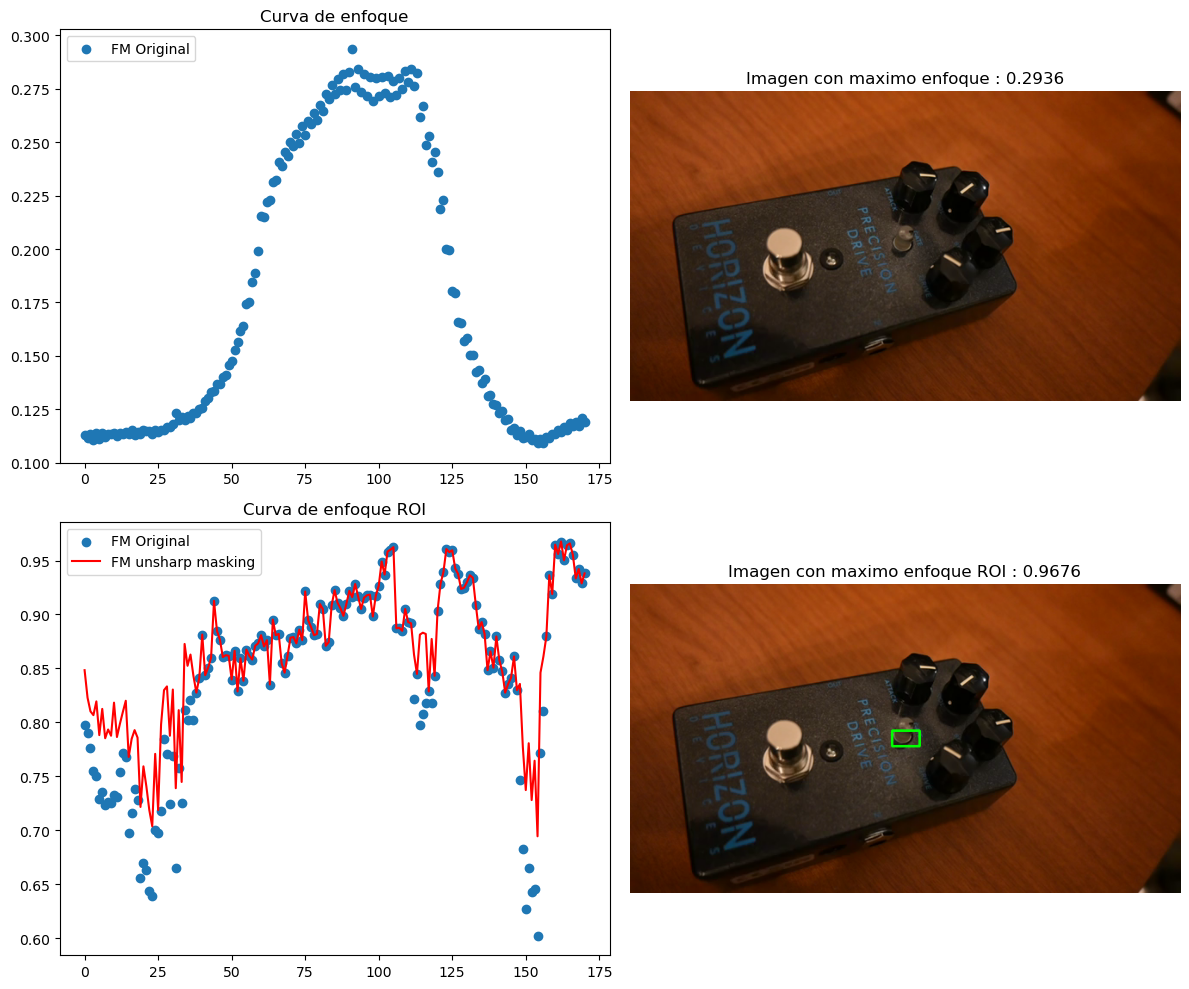

In [8]:
#Ejecucion del analisis
#indicar video a analizar, porcentaje de area central para enfoque, el rango de porcentajes bajo maximo enfoque para hacer unsharp masking y el k para 
#Parametros
video_original = 'focus_video.mov' #video a ser analizado
pct_roi = 0.05 #porcentaje del area central (ROI)
pct_ini = 0.25 #porcentaje inicial de diferencia contra el punto de maximo enfoque para aplicar unsharp masking
pct_fin = 0.15 #porcentaje maximo de diferencia contra el punto de maximo enfoque base para aplicar unsharp masking
factor_k = 1.5 # factor K para el unsharp masking
fm_analisis(video_original,pct_roi,pct_ini,pct_fin,factor_k)